In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter

In [ ]:
hidden_size = 64
seq_length = 25
learning_rate = 0.03
epochs = 20

In [ ]:
data = open("input.txt", "r").read()
chars = list(set(data))
data_size, vocab_size = len(data), len(chars)

char_to_ix = {ch:i for i,ch in enumerate(chars)}
ix_to_char = {i:ch for i,ch in enumerate(chars)}

# ---------- Initialize weights ----------
Wxh = np.random.randn(hidden_size, vocab_size)*0.01
Whh = np.random.randn(hidden_size, hidden_size)*0.01
Why = np.random.randn(vocab_size, hidden_size)*0.01

bh = np.zeros((hidden_size,1))
by = np.zeros((vocab_size,1))

In [ ]:
def softmax(x):
    e = np.exp(x - np.max(x))
    return e / np.sum(e)

In [ ]:
def loss_fun(inputs, targets, hprev):

    xs, hs, ys, ps = {}, {}, {}, {}
    hs[-1] = np.copy(hprev)
    loss = 0

    # Forward
    for t in range(len(inputs)):
        xs[t] = np.zeros((vocab_size,1))
        xs[t][inputs[t]] = 1

        hs[t] = np.tanh(
            np.dot(Wxh, xs[t]) +
            np.dot(Whh, hs[t-1]) +
            bh
        )

        ys[t] = np.dot(Why, hs[t]) + by
        ps[t] = softmax(ys[t])

        loss += -np.log(ps[t][targets[t],0])

    # Backward (BPTT)
    dWxh = np.zeros_like(Wxh)
    dWhh = np.zeros_like(Whh)
    dWhy = np.zeros_like(Why)
    dbh = np.zeros_like(bh)
    dby = np.zeros_like(by)

    dhnext = np.zeros_like(hs[0])

    grad_norms = []

    for t in reversed(range(len(inputs))):

        dy = np.copy(ps[t])
        dy[targets[t]] -= 1

        dWhy += np.dot(dy, hs[t].T)
        dby += dy

        dh = np.dot(Why.T, dy) + dhnext
        dhraw = (1 - hs[t]**2) * dh

        dbh += dhraw
        dWxh += np.dot(dhraw, xs[t].T)
        dWhh += np.dot(dhraw, hs[t-1].T)

        dhnext = np.dot(Whh.T, dhraw)

        grad_norms.append(np.linalg.norm(dhraw))

    # Gradient clipping
    for dparam in [dWxh,dWhh,dWhy,dbh,dby]:
        np.clip(dparam, -5, 5, out=dparam)

    return loss, dWxh,dWhh,dWhy,dbh,dby, hs[len(inputs)-1], grad_norms

In [ ]:
n = 0
p = 0
hprev = np.zeros((hidden_size,1))

writer = SummaryWriter("runs/scratch_vanilla_rnn")
losses = []
all_grad_norms = []
step = 0

In [ ]:
while n < epochs * 100:

    if p + seq_length + 1 >= len(data):
        hprev = np.zeros((hidden_size,1))
        p = 0

    inputs = [char_to_ix[ch] for ch in data[p:p+seq_length]]
    targets = [char_to_ix[ch] for ch in data[p+1:p+seq_length+1]]

    loss, dWxh,dWhh,dWhy,dbh,dby, hprev, grad_norms = loss_fun(inputs,targets,hprev)

    Wxh -= learning_rate*dWxh
    Whh -= learning_rate*dWhh
    Why -= learning_rate*dWhy
    bh  -= learning_rate*dbh
    by  -= learning_rate*dby

    losses.append(loss)
    all_grad_norms.extend(grad_norms)
    writer.add_scalar("Loss/train", float(loss), step)
    step += 1

    p += seq_length
    n += 1


writer.close()

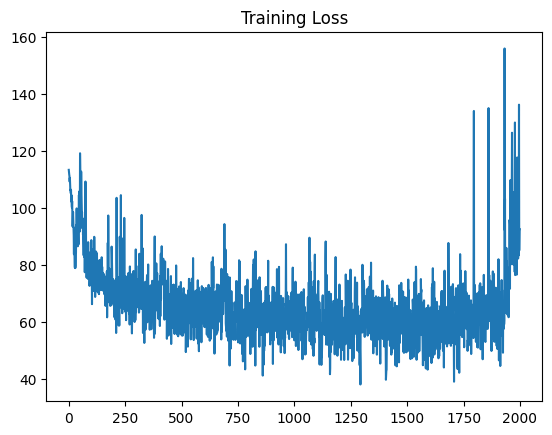

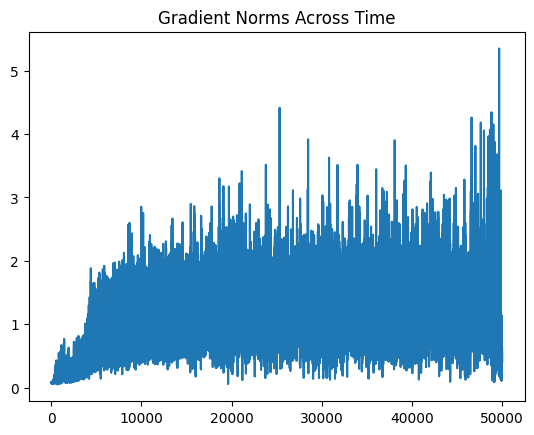

In [ ]:
plt.plot(losses)
plt.title("Training Loss")
plt.show()

plt.plot(all_grad_norms)
plt.title("Gradient Norms Across Time")
plt.show()